In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import gymnasium as gym
import numpy as np

custom_map = [
    "FSFF",
    "FHFH",
    "FFFG",
    "HFFH"
]

env = gym.make(
    "FrozenLake-v1",
    is_slippery=False,
    render_mode="rgb_array",
    desc=custom_map
)

# Initialize environment for SARSA
obs_space_size = env.observation_space.n
action_space_size = env.action_space.n

# Initialize Q-table
Q = np.zeros((obs_space_size, action_space_size))

print("Custom FrozenLake Environment Created!")
print("Map Layout:")
for row in custom_map:
    print(row)

Custom FrozenLake Environment Created!
Map Layout:
FSFF
FHFH
FFFG
HFFH


In [9]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1
gamma = 0.95

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

In [10]:
# -------------------------------------------------
# Initialize Q-table
# This has already been done in cell 2.
# Q = np.zeros((obs_space_size, action_space_size))
# -------------------------------------------------



# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    """
    if np.random.rand() < epsilon:
        # Explore: choose a random action
        return env.action_space.sample()
    else:
        # Exploit: choose the action with the highest Q-value for the current state
        return np.argmax(Q[state, :])

In [11]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):
    state, _ = env.reset() # Reset the environment for a new episode
    action = epsilon_greedy_action(state, epsilon) # Select initial action
    total_reward = 0

    for step in range(max_steps_per_episode):
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Select the next action using epsilon-greedy policy
        next_action = epsilon_greedy_action(next_state, epsilon)

        # SARSA update rule
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * Q[next_state, next_action] - Q[state, action]
        )

        state = next_state
        action = next_action
        total_reward += reward

        if done:
            break

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)


# Derive the optimal policy and state values from the learned Q-table
learned_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)

print("SARSA training complete!")

SARSA training complete!


In [12]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [13]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)



Final Q-table:
[[0.498 0.389 0.785 0.401]
 [0.736 0.    0.813 0.768]
 [0.752 0.884 0.728 0.761]
 [0.791 0.    0.566 0.598]
 [0.249 0.546 0.    0.217]
 [0.    0.    0.    0.   ]
 [0.    0.947 0.    0.815]
 [0.    0.    0.    0.   ]
 [0.247 0.    0.802 0.174]
 [0.55  0.527 0.945 0.   ]
 [0.86  0.868 1.    0.871]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.355 0.54  0.753]
 [0.558 0.719 0.    0.938]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.785 0.813 0.884 0.791]
 [0.546 0.    0.947 0.   ]
 [0.802 0.945 1.    0.   ]
 [0.    0.753 0.938 0.   ]]

Learned Policy:
[['R' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'R' 'L']
 ['L' 'U' 'U' 'L']]

Average reward over last 1000 episodes: 0.972


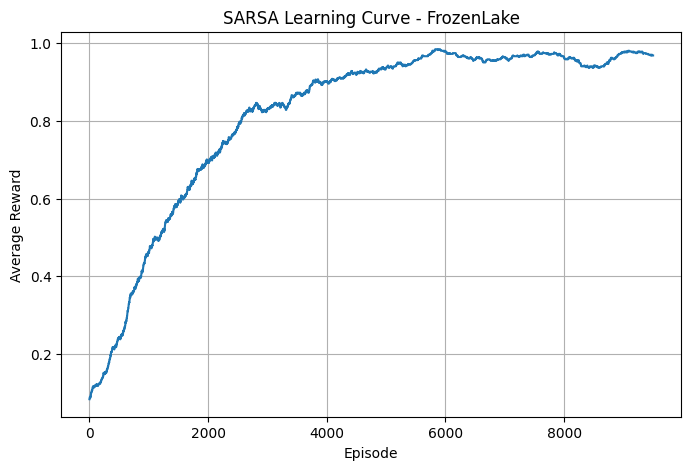

In [14]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()